<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import string
from collections import Counter

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK Resources
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [2]:
comments = [
    "The new product launch was impressive and exceeded my expectations.",
    "I am disappointed with the delivery service.",
    "The customer support team resolved my issue very quickly.",
    "This is one of the best products I have ever purchased.",
    "The app interface is confusing and difficult to use.",
    "Excellent quality and affordable price.",
    "The latest advertisement was creative and engaging.",
    "I received a defective item and requested a replacement.",
    "The battery backup is much better after the recent update.",
    "Very poor packaging. The box was damaged.",
    "I love the new features introduced in this version.",
    "The checkout process was smooth and hassle-free.",
    "Customer service needs significant improvement.",
    "Fast shipping and secure packaging.",
    "The product does not match the description provided.",
    "Highly satisfied with my overall shopping experience.",
    "The website loads slowly on my mobile phone.",
    "The design looks modern and attractive.",
    "I will definitely recommend this product to my friends.",
    "The return process was quick and simple.",
    "The product quality has improved compared to last year.",
    "The promotional offer was worth the money.",
    "I faced payment issues while placing the order.",
    "The staff were polite and answered all my questions.",
    "Amazing performance and excellent durability.",
    "The product arrived later than expected.",
    "I appreciate the quick response from the support team.",
    "The color and finish of the product are beautiful.",
    "This brand always delivers high-quality products.",
    "The application crashes every time I open it.",
    "The delivery executive was professional and friendly.",
    "Very satisfied with the overall service provided.",
    "The latest software update fixed many issues.",
    "The product is average and could be improved.",
    "I received the wrong item in my order.",
    "The sound quality is crystal clear.",
    "Customer care did not respond to my emails.",
    "The shopping experience was smooth and enjoyable.",
    "Excellent packaging and timely delivery.",
    "The price is slightly high but the quality is worth it.",
    "I am unhappy with the warranty service.",
    "The new campaign attracted many customers.",
    "The installation process was simple and quick.",
    "The accessories included are very useful.",
    "The product stopped working after a few days.",
    "Fantastic design and premium build quality.",
    "The response time of the app is very fast.",
    "The online support chat was extremely helpful.",
    "Overall, this product offers great value for money.",
    "I would not recommend this product because of its poor quality."

]
df = pd.DataFrame({
    "Comment": comments
})

print("First Five Comments")
print(df.head())

First Five Comments
                                             Comment
0  The new product launch was impressive and exce...
1       I am disappointed with the delivery service.
2  The customer support team resolved my issue ve...
3  This is one of the best products I have ever p...
4  The app interface is confusing and difficult t...


In [3]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Comment"] = df["Comment"].apply(clean_text)

print("\nCleaned Comments")
print(df[["Comment","Clean_Comment"]].head())



Cleaned Comments
                                             Comment  \
0  The new product launch was impressive and exce...   
1       I am disappointed with the delivery service.   
2  The customer support team resolved my issue ve...   
3  This is one of the best products I have ever p...   
4  The app interface is confusing and difficult t...   

                                       Clean_Comment  
0  new product launch impressive exceeded expecta...  
1                      disappointed delivery service  
2       customer support team resolved issue quickly  
3                   one best products ever purchased  
4              app interface confusing difficult use  


In [4]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Comment"].apply(get_sentiment)

print("\nSentiment Results")
print(df[["Comment","Sentiment"]])


Sentiment Results
                                              Comment Sentiment
0   The new product launch was impressive and exce...  Positive
1        I am disappointed with the delivery service.  Negative
2   The customer support team resolved my issue ve...  Positive
3   This is one of the best products I have ever p...  Positive
4   The app interface is confusing and difficult t...  Negative
5             Excellent quality and affordable price.  Positive
6   The latest advertisement was creative and enga...  Positive
7   I received a defective item and requested a re...  Negative
8   The battery backup is much better after the re...  Positive
9           Very poor packaging. The box was damaged.  Negative
10  I love the new features introduced in this ver...  Positive
11   The checkout process was smooth and hassle-free.   Neutral
12    Customer service needs significant improvement.  Positive
13                Fast shipping and secure packaging.  Positive
14  The product does 

In [5]:
all_words = " ".join(df["Clean_Comment"]).split()

word_frequency = Counter(all_words)

print("\nTop 10 Trending Topics")

for word, count in word_frequency.most_common(10):
    print(word, ":", count)


Top 10 Trending Topics
product : 10
quality : 6
service : 4
new : 3
delivery : 3
customer : 3
support : 3
excellent : 3
packaging : 3
process : 3


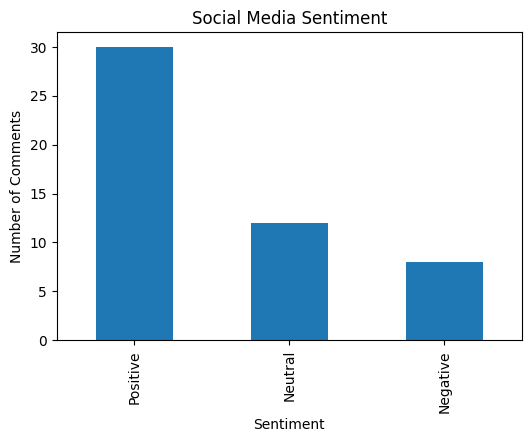

In [6]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

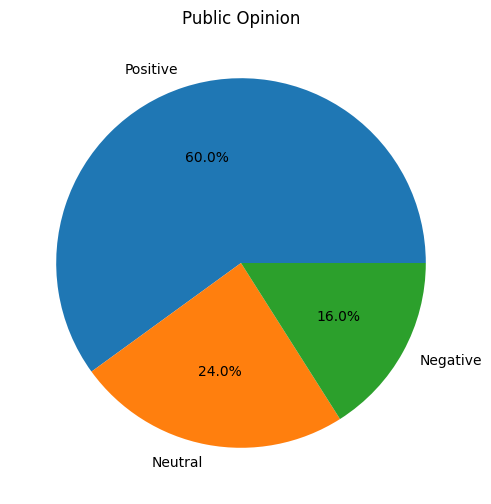

In [7]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Public Opinion")

plt.show()

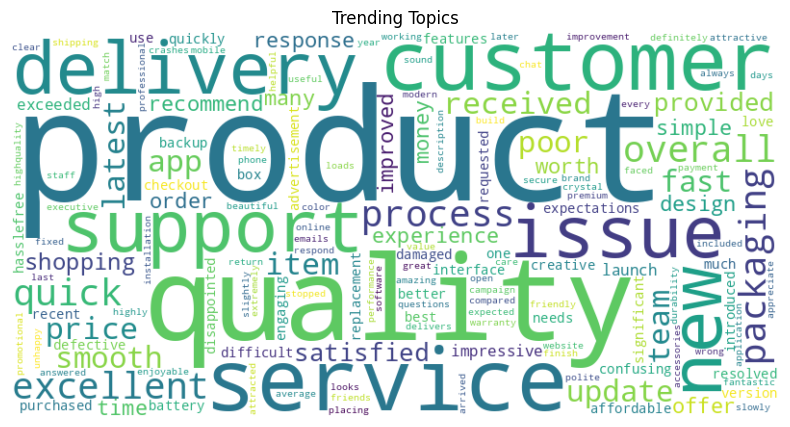

In [8]:
text = " ".join(df["Clean_Comment"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Trending Topics")

plt.show()

In [9]:
print("\nPublic Opinion Report")
print("----------------------------")

print(df["Sentiment"].value_counts())


Public Opinion Report
----------------------------
Sentiment
Positive    30
Neutral     12
Negative     8
Name: count, dtype: int64


In [10]:
df.to_csv("Social_Media_Analysis_Output.csv", index=False)

print("\nAnalysis Completed Successfully!")
print("Output saved as Social_Media_Analysis_Output.csv")


Analysis Completed Successfully!
Output saved as Social_Media_Analysis_Output.csv
